## 0. Setup

In [1]:
import os, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
import tensorflow as tf
from tensorflow import keras

DATA_ROOT = Path('//kaggle/input/datasets/qasimmaajid/isolated-signs')
OUT  = Path('/kaggle/working')
MODEL_OUT = OUT / 'models'
LOG_OUT   = OUT / 'logs'
MODEL_OUT.mkdir(parents=True, exist_ok=True)
LOG_OUT.mkdir(parents=True, exist_ok=True)

print('TF version:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))
print('Data root exists:', DATA_ROOT.exists())
if DATA_ROOT.exists():
    print('Files:', sorted(p.name for p in DATA_ROOT.iterdir()))

2026-05-05 04:34:01.778358: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777955642.370357      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777955642.497864      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777955643.565326      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777955643.565391      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777955643.565394      57 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Data root exists: True
Files: ['isolated_signs_processed.pkl']


## 1. Load the processed sequences

In [2]:
DROPPED_SIGNS = {
    'go', 'grandma', 'grandpa', 'mom', 'dad',
    'sleep', 'sleepy', 'thankyou', 'happy', 'look',
}

df = pd.read_pickle(DATA_ROOT / 'isolated_signs_processed.pkl')
print(f'Before filter: {len(df)} sequences, {df["sign"].nunique()} signs')

if DROPPED_SIGNS:
    df = df[~df['sign'].isin(DROPPED_SIGNS)].reset_index(drop=True)
    print(f'After filter:  {len(df)} sequences, {df["sign"].nunique()} signs')

BASE_DIM = df['features'].iloc[0].shape[1]  # 85 — raw positional features
print(f'Base feature dim per frame: {BASE_DIM}')
assert BASE_DIM == 85

print('\nPer-sign counts:')
print(df['sign'].value_counts().to_string())
print('\nFrame length stats:')
print(df['n_frames'].describe())

Before filter: 9976 sequences, 30 signs
After filter:  6709 sequences, 20 signs
Base feature dim per frame: 85

Per-sign counts:
sign
listen     391
drink      375
sad        371
food       370
bye        369
home       368
water      362
finish     351
see        348
please     348
cat        342
yes        338
hello      329
brother    326
dog        319
hungry     295
wait       283
no         278
have       276
now        270

Frame length stats:
count    6709.000000
mean       26.963482
std        28.101852
min         5.000000
25%        11.000000
50%        17.000000
75%        30.000000
max       231.000000
Name: n_frames, dtype: float64


## 2. Add velocity features (85-d → 127-d)

Append per-frame Δx,Δy for all 21 hand landmarks (42-d) computed from consecutive
frames.  First frame of each sequence gets zero velocity.

This matches the inference-time `SequenceFeatureBuffer` which does the same
computation live on the phone's frame stream.

**Final layout (127-d):**
- `[0:63)`  hand shape (wrist-relative, unit-scaled)
- `[63:85)` wrist pos + face anchors + elbows in body frame
- `[85:127)` hand landmark velocity (21 × Δx, Δy)

In [3]:
HAND_XY_IDX = np.array([i * 3 + j for i in range(21) for j in range(2)])  # (42,)
VELOCITY_DIM = len(HAND_XY_IDX)   # 42
INPUT_DIM = BASE_DIM + VELOCITY_DIM  # 127

def add_velocity(frames: np.ndarray) -> np.ndarray:
    """(T, 85) -> (T, 127).  First frame velocity is zero."""
    hand_xy = frames[:, HAND_XY_IDX]           # (T, 42)
    velocity = np.zeros_like(hand_xy)
    velocity[1:] = hand_xy[1:] - hand_xy[:-1]
    return np.concatenate([frames, velocity], axis=1).astype(np.float32)

df['features'] = df['features'].apply(add_velocity)
print(f'Feature dim after velocity: {df["features"].iloc[0].shape[1]}')  # 127
assert df['features'].iloc[0].shape[1] == INPUT_DIM

Feature dim after velocity: 127


## 3. Pad/truncate every sequence to TARGET_LEN frames

In [4]:
TARGET_LEN = 45   # longer window captures more trajectory

def pad_or_truncate(frames: np.ndarray, target_len: int = TARGET_LEN) -> np.ndarray:
    n = len(frames)
    if n >= target_len:
        start = (n - target_len) // 2
        return frames[start:start + target_len]
    padded = np.zeros((target_len, frames.shape[1]), dtype=np.float32)
    padded[:n] = frames
    return padded

X_seq = np.stack([pad_or_truncate(s) for s in df['features']])  # (N, 45, 127)
print('Sequence tensor shape:', X_seq.shape, 'dtype:', X_seq.dtype)

Sequence tensor shape: (6709, 45, 127) dtype: float32


## 4. Encode string labels to integers

In [5]:
labels_sorted = sorted(df['sign'].unique())
label_to_idx = {lab: i for i, lab in enumerate(labels_sorted)}
idx_to_label = {i: lab for lab, i in label_to_idx.items()}

y = np.array([label_to_idx[s] for s in df['sign']], dtype=np.int64)
print(f'NUM_CLASSES = {len(labels_sorted)}')
print('Classes:', labels_sorted)

with open(MODEL_OUT / 'phrases_label_encoder.pkl', 'wb') as f:
    pickle.dump({'label_to_idx': label_to_idx, 'idx_to_label': idx_to_label}, f)

NUM_CLASSES = 20
Classes: ['brother', 'bye', 'cat', 'dog', 'drink', 'finish', 'food', 'have', 'hello', 'home', 'hungry', 'listen', 'no', 'now', 'please', 'sad', 'see', 'wait', 'water', 'yes']


## 5. Stratified train/val/test split (80/10/10)

In [6]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(X_seq))
train_idx, temp_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)
val_idx,   test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42, stratify=y[temp_idx])

X_train, y_train = X_seq[train_idx], y[train_idx]
X_val,   y_val   = X_seq[val_idx],   y[val_idx]
X_test,  y_test  = X_seq[test_idx],  y[test_idx]

print(f'train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}')

train: (5367, 45, 127), val: (671, 45, 127), test: (671, 45, 127)


## 6. Class weights

In [7]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print('Class weights (highest 5):')
for cls, w in sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f'  {idx_to_label[cls]:10s} weight={w:.3f}')

Class weights (highest 5):
  now        weight=1.242
  have       weight=1.214
  no         weight=1.203
  wait       weight=1.187
  hungry     weight=1.137


## 7. Time-warp augmentation (offline, 50 % of training sequences)

Randomly stretch/compress sequences along the time axis using linear interpolation,
then re-pad/center-crop back to TARGET_LEN.  Makes the model robust to signing
speed variation without needing tf.py_function overhead in the tf.data pipeline.

In [8]:
def time_warp_sequence(frames: np.ndarray, max_warp: float = 0.25) -> np.ndarray:
    T, D = frames.shape
    nonzero = np.any(frames != 0, axis=1)
    content_len = int(nonzero.sum()) if nonzero.any() else T
    if content_len < 2:
        return frames
    content = frames[:content_len]
    warp = np.random.uniform(1 - max_warp, 1 + max_warp)
    new_T = max(2, int(round(content_len * warp)))
    warped = interp1d(
        np.linspace(0, 1, content_len), content, axis=0, kind='linear'
    )(np.linspace(0, 1, new_T)).astype(np.float32)
    if new_T >= TARGET_LEN:
        start = (new_T - TARGET_LEN) // 2
        return warped[start:start + TARGET_LEN]
    padded = np.zeros((TARGET_LEN, D), dtype=np.float32)
    padded[:new_T] = warped
    return padded

rng = np.random.default_rng(42)
warp_mask = rng.random(len(X_train)) < 0.5
X_train_aug = X_train.copy()
for i in np.where(warp_mask)[0]:
    X_train_aug[i] = time_warp_sequence(X_train[i])
print(f'Time-warped {warp_mask.sum()} / {len(X_train)} training sequences')

Time-warped 2740 / 5367 training sequences


## 8. Spatial augmentation pipeline (tf.data)

Per-frame rotation, scale, translation, and noise.  Velocity features are rotated
by the same angle and scaled by the same factor as the hand shape so both feature
groups stay geometrically consistent.

In [9]:
def augment_sequence(features, label):
    # features: (TARGET_LEN, 127)
    hand_shape = features[:, :63]    # (T, 63)
    body_ctx   = features[:, 63:85]  # (T, 22)
    velocity   = features[:, 85:]    # (T, 42)

    angle = tf.random.uniform([], -0.26, 0.26)
    cos_a, sin_a = tf.cos(angle), tf.sin(angle)

    # Rotate + scale + translate hand shape
    seq = tf.reshape(hand_shape, (TARGET_LEN, 21, 3))
    x  = seq[..., 0] * cos_a - seq[..., 1] * sin_a
    y_ = seq[..., 0] * sin_a + seq[..., 1] * cos_a
    seq = tf.stack([x, y_, seq[..., 2]], axis=-1)
    scale = tf.random.uniform([], 0.9, 1.1)
    seq  *= scale
    seq  += tf.random.uniform([3], -0.05, 0.05)
    seq  += tf.random.normal(tf.shape(seq), stddev=0.005)
    hand_shape = tf.reshape(seq, (TARGET_LEN, 63))

    # Rotate + scale velocity by same transform (keeps geometry consistent)
    vel = tf.reshape(velocity, (TARGET_LEN, 21, 2))
    vx  = vel[..., 0] * cos_a - vel[..., 1] * sin_a
    vy  = vel[..., 0] * sin_a + vel[..., 1] * cos_a
    vel = tf.stack([vx, vy], axis=-1) * scale
    vel += tf.random.normal(tf.shape(vel), stddev=0.002)
    velocity = tf.reshape(vel, (TARGET_LEN, 42))

    body_ctx = body_ctx + tf.random.normal(tf.shape(body_ctx), stddev=0.01)

    return tf.concat([hand_shape, body_ctx, velocity], axis=1), label


BATCH = 128
train_ds = (tf.data.Dataset.from_tensor_slices((X_train_aug.astype(np.float32), y_train))
            .map(augment_sequence, num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(4096).batch(BATCH).prefetch(tf.data.AUTOTUNE))
val_ds   = (tf.data.Dataset.from_tensor_slices((X_val.astype(np.float32), y_val))
            .batch(BATCH).prefetch(tf.data.AUTOTUNE))
print('train_ds element_spec:', train_ds.element_spec)

I0000 00:00:1777955764.754024      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777955764.759880      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


train_ds element_spec: (TensorSpec(shape=(None, 45, 127), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))


## 9. Model — Bidirectional LSTM + Attention pooling

Changes from v1 (stacked unidirectional LSTM):
- **BiLSTM**: each layer reads the sequence both forward and backward, giving the
  model full context at every timestep (valid for isolated-sign recognition where
  the whole window is known upfront)
- **Attention pooling**: learns which frames were most discriminative rather than
  relying solely on the final hidden state
- **Larger input**: 127-d (85 base + 42 velocity) vs 85-d

In [10]:
NUM_CLASSES = len(labels_sorted)


class AttentionPooling(keras.layers.Layer):
    """Soft attention over the time axis, respects Masking."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.score = keras.layers.Dense(1)

    def call(self, x, mask=None):
        e = tf.squeeze(self.score(x), axis=-1)           # (batch, T)
        if mask is not None:
            e += (1.0 - tf.cast(mask, tf.float32)) * -1e9
        weights = tf.nn.softmax(e, axis=-1)               # (batch, T)
        return tf.reduce_sum(x * tf.expand_dims(weights, -1), axis=1)

    def get_config(self):
        return super().get_config()


inputs  = keras.Input(shape=(TARGET_LEN, INPUT_DIM))
x       = keras.layers.Masking(mask_value=0.0)(inputs)
x       = keras.layers.Bidirectional(
              keras.layers.LSTM(128, return_sequences=True, dropout=0.2)
          )(x)
x       = keras.layers.Bidirectional(
              keras.layers.LSTM(64, return_sequences=True, dropout=0.2)
          )(x)
x       = AttentionPooling()(x)
x       = keras.layers.Dense(128, activation='relu')(x)
x       = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy',
             keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3'),
             keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top5')],
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'attention_pooling' (of type AttentionPooling) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 45, 127)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 45, 127)   │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 45, 127)   │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 45)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 45, 256)   │    262,144 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 45, 128)   │    164,352 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_pooling   │ (None, 128)       │        129 │ bidirectional_1[… │
│ (AttentionPooling)  │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ attention_poolin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 20)        │      2,580 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 445,717 (1.70 MB)

 Trainable params: 445,717 (1.70 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Train

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                                       min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(str(MODEL_OUT / 'phrases_model_bilstm.h5'),
                                     monitor='val_accuracy', save_best_only=True),
    keras.callbacks.CSVLogger(str(LOG_OUT / 'phrases_training.csv')),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=120,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/120


I0000 00:00:1777955785.860079     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


42/42 - 10s - 230ms/step - accuracy: 0.1940 - loss: 2.5124 - top3: 0.4548 - top5: 0.6208 - val_accuracy: 0.4098 - val_loss: 1.8440 - val_top3: 0.7392 - val_top5: 0.8405 - learning_rate: 1.0000e-03
Epoch 2/120


42/42 - 2s - 39ms/step - accuracy: 0.3952 - loss: 1.7727 - top3: 0.7336 - top5: 0.8584 - val_accuracy: 0.5812 - val_loss: 1.3738 - val_top3: 0.8301 - val_top5: 0.9225 - learning_rate: 1.0000e-03
Epoch 3/120


42/42 - 2s - 38ms/step - accuracy: 0.5279 - loss: 1.4368 - top3: 0.8152 - top5: 0.9052 - val_accuracy: 0.6453 - val_loss: 1.1097 - val_top3: 0.8644 - val_top5: 0.9463 - learning_rate: 1.0000e-03
Epoch 4/120


...

42/42 - 2s - 36ms/step - accuracy: 0.8739 - loss: 0.4029 - top3: 0.9666 - top5: 0.9819 - val_accuracy: 0.9106 - val_loss: 0.3396 - val_top3: 0.9642 - val_top5: 0.9747 - learning_rate: 1.0000e-03
Epoch 34/120
42/42 - 1s - 35ms/step - accuracy: 0.8726 - loss: 0.4014 - top3: 0.9661 - top5: 0.9812 - val_accuracy: 0.8972 - val_loss: 0.3584 - val_top3: 0.9657 - val_top5: 0.9732 - learning_rate: 1.0000e-03
Epoch 35/120
42/42 - 1s - 34ms/step - accuracy: 0.8726 - loss: 0.4020 - top3: 0.9681 - top5: 0.9832 - val_accuracy: 0.9046 - val_loss: 0.3545 - val_top3: 0.9657 - val_top5: 0.9747 - learning_rate: 1.0000e-03
Epoch 36/120
42/42 - 1s - 35ms/step - accuracy: 0.8776 - loss: 0.3848 - top3: 0.9694 - top5: 0.9830 - val_accuracy: 0.9046 - val_loss: 0.3205 - val_top3: 0.9702 - val_top5: 0.9762 - learning_rate: 1.0000e-03
Epoch 37/120
42/42 - 2s - 36ms/step - accuracy: 0.8837 - loss: 0.3773 - top3: 0.9691 - top5: 0.9838 - val_accuracy: 0.9061 - val_loss: 0.3559 - val_top3: 0.9613 - val_top5: 0.9717 -

42/42 - 2s - 37ms/step - accuracy: 0.9089 - loss: 0.2827 - top3: 0.9782 - top5: 0.9877 - val_accuracy: 0.9136 - val_loss: 0.3256 - val_top3: 0.9613 - val_top5: 0.9776 - learning_rate: 5.0000e-04
Epoch 47/120
42/42 - 2s - 37ms/step - accuracy: 0.9145 - loss: 0.2738 - top3: 0.9771 - top5: 0.9881 - val_accuracy: 0.9121 - val_loss: 0.3193 - val_top3: 0.9702 - val_top5: 0.9806 - learning_rate: 2.5000e-04
Epoch 48/120


42/42 - 2s - 37ms/step - accuracy: 0.9199 - loss: 0.2589 - top3: 0.9775 - top5: 0.9868 - val_accuracy: 0.9165 - val_loss: 0.3166 - val_top3: 0.9672 - val_top5: 0.9791 - learning_rate: 2.5000e-04
Epoch 49/120
42/42 - 2s - 36ms/step - accuracy: 0.9195 - loss: 0.2595 - top3: 0.9793 - top5: 0.9883 - val_accuracy: 0.9151 - val_loss: 0.3218 - val_top3: 0.9672 - val_top5: 0.9791 - learning_rate: 2.5000e-04
Epoch 50/120
42/42 - 1s - 36ms/step - accuracy: 0.9135 - loss: 0.2687 - top3: 0.9788 - top5: 0.9884 - val_accuracy: 0.9121 - val_loss: 0.3088 - val_top3: 0.9687 - val_top5: 0.9791 - learning_rate: 2.5000e-04
Epoch 51/120
42/42 - 1s - 35ms/step - accuracy: 0.9135 - loss: 0.2642 - top3: 0.9808 - top5: 0.9886 - val_accuracy: 0.9091 - val_loss: 0.3152 - val_top3: 0.9642 - val_top5: 0.9791 - learning_rate: 2.5000e-04
Epoch 52/120
42/42 - 1s - 35ms/step - accuracy: 0.9169 - loss: 0.2643 - top3: 0.9793 - top5: 0.9892 - val_accuracy: 0.9046 - val_loss: 0.3291 - val_top3: 0.9672 - val_top5: 0.9762 -

42/42 - 2s - 36ms/step - accuracy: 0.9201 - loss: 0.2580 - top3: 0.9801 - top5: 0.9888 - val_accuracy: 0.9180 - val_loss: 0.3192 - val_top3: 0.9657 - val_top5: 0.9791 - learning_rate: 2.5000e-04
Epoch 56/120


42/42 - 2s - 36ms/step - accuracy: 0.9206 - loss: 0.2533 - top3: 0.9797 - top5: 0.9894 - val_accuracy: 0.9210 - val_loss: 0.3072 - val_top3: 0.9702 - val_top5: 0.9791 - learning_rate: 1.2500e-04
Epoch 57/120
42/42 - 1s - 35ms/step - accuracy: 0.9240 - loss: 0.2414 - top3: 0.9810 - top5: 0.9886 - val_accuracy: 0.9180 - val_loss: 0.3115 - val_top3: 0.9687 - val_top5: 0.9791 - learning_rate: 1.2500e-04
Epoch 58/120
42/42 - 1s - 35ms/step - accuracy: 0.9201 - loss: 0.2575 - top3: 0.9771 - top5: 0.9888 - val_accuracy: 0.9195 - val_loss: 0.3136 - val_top3: 0.9672 - val_top5: 0.9791 - learning_rate: 1.2500e-04
Epoch 59/120
42/42 - 1s - 36ms/step - accuracy: 0.9232 - loss: 0.2518 - top3: 0.9786 - top5: 0.9884 - val_accuracy: 0.9210 - val_loss: 0.3032 - val_top3: 0.9657 - val_top5: 0.9806 - learning_rate: 1.2500e-04
Epoch 60/120
42/42 - 1s - 35ms/step - accuracy: 0.9281 - loss: 0.2408 - top3: 0.9797 - top5: 0.9881 - val_accuracy: 0.9210 - val_loss: 0.3066 - val_top3: 0.9657 - val_top5: 0.9776 -

## 11. Training curves

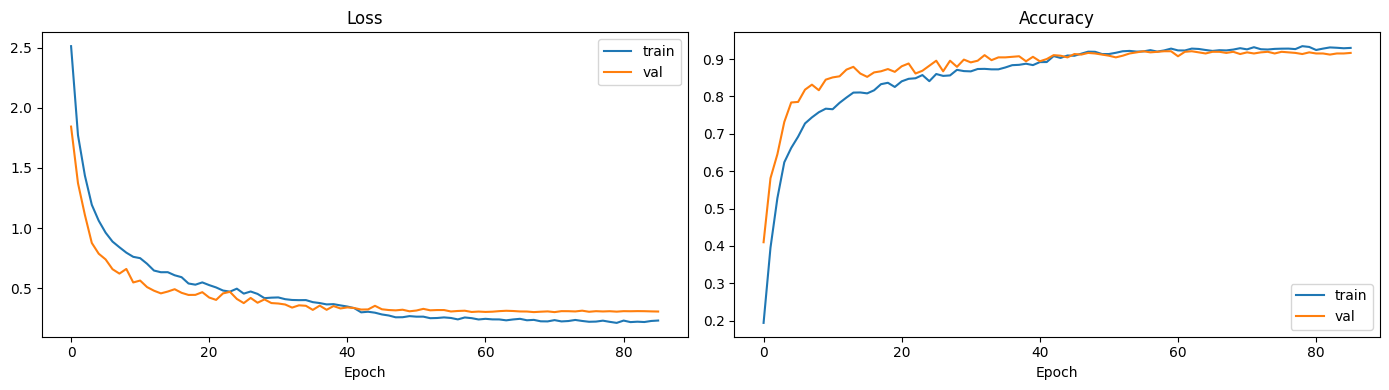

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig(LOG_OUT / 'phrases_training_curves.png', dpi=150)
plt.show()

## 12. Evaluate on the held-out test set

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred_proba = model.predict(X_test.astype(np.float32), batch_size=BATCH, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

test_acc = accuracy_score(y_test, y_pred)
top3 = np.mean([y_test[i] in np.argsort(y_pred_proba[i])[-3:] for i in range(len(y_test))])
top5 = np.mean([y_test[i] in np.argsort(y_pred_proba[i])[-5:] for i in range(len(y_test))])

print(f'Top-1 accuracy: {test_acc:.4f}')
print(f'Top-3 accuracy: {top3:.4f}')
print(f'Top-5 accuracy: {top5:.4f}')

label_names = [idx_to_label[i] for i in sorted(idx_to_label)]
report = classification_report(y_test, y_pred, target_names=label_names,
                                output_dict=True, zero_division=0)
pd.DataFrame(report).T.to_csv(LOG_OUT / 'phrases_classification_report.csv')
print('\nPer-class report:')
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

Top-1 accuracy: 0.9091
Top-3 accuracy: 0.9523
Top-5 accuracy: 0.9687

Per-class report:
              precision    recall  f1-score   support

     brother       1.00      0.78      0.88        32
         bye       0.83      0.92      0.87        37
         cat       0.94      0.94      0.94        34
         dog       0.75      0.84      0.79        32
       drink       0.91      0.78      0.84        37
      finish       0.89      0.94      0.92        35
        food       0.89      0.89      0.89        37
        have       0.86      0.86      0.86        28
       hello       0.88      0.91      0.90        33
        home       0.92      0.97      0.95        37
      hungry       0.93      0.90      0.92        30
      listen       0.95      0.92      0.94        39
          no       0.96      0.93      0.95        28
         now       0.92      0.89      0.91        27
      please       0.92      0.97      0.94        35
         sad       0.94      0.92      0.93    

## 13. Confusion matrix

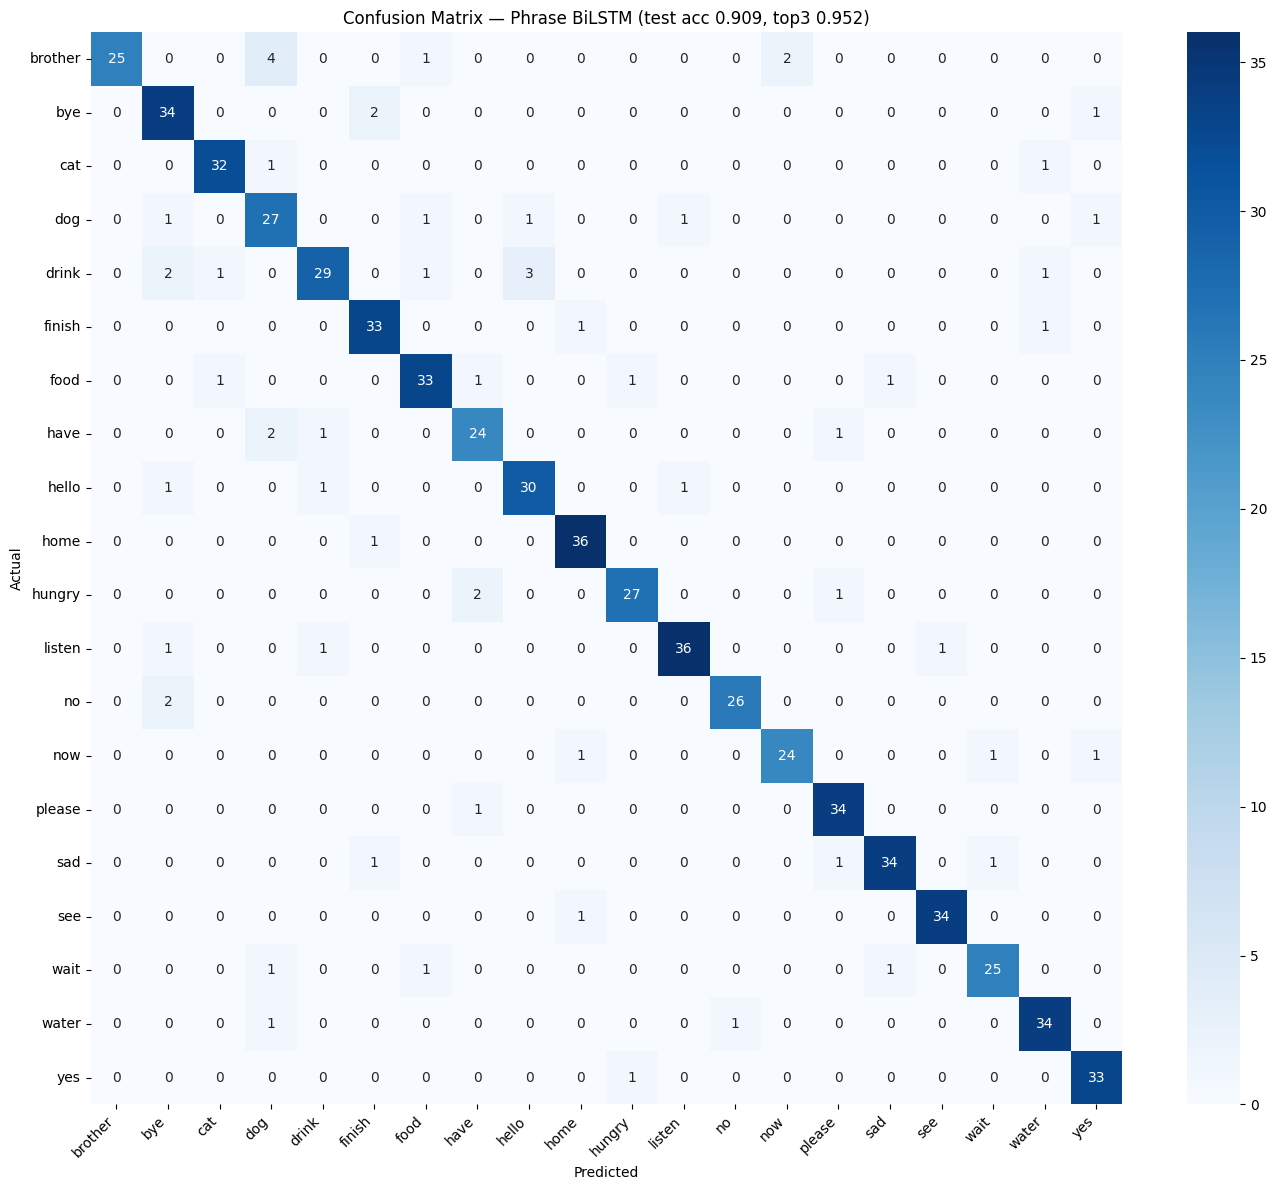

In [14]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names,
            cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix — Phrase BiLSTM (test acc {test_acc:.3f}, top3 {top3:.3f})')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(LOG_OUT / 'phrases_confusion_matrix.png', dpi=150)
plt.show()

## 14. Weak signs and confused pairs

In [17]:
weak = [(lab, report[lab]['f1-score']) for lab in label_names if report[lab]['f1-score'] < 0.80]
weak.sort(key=lambda x: x[1])
print('Weak signs (F1 < 0.80):')
for lab, f1 in weak:
    print(f'  {lab:10s} F1={f1:.3f}')
if not weak:
    print('  (none)')

print('\nMost-confused pairs (>10% misclassified):')
for i, true_lab in enumerate(label_names):
    total = cm[i].sum()
    if total == 0: continue
    for j, pred_lab in enumerate(label_names):
        if i != j and cm[i][j] > 0.10 * total:
            print(f'  {true_lab} -> {pred_lab}: {cm[i][j]} ({100*cm[i][j]/total:.1f}%)')

Weak signs (F1 < 0.80):
  dog        F1=0.794

Most-confused pairs (>10% misclassified):
  brother -> dog: 4 (12.5%)


## 15. Convert to TFLite

Rebuild with `recurrent_dropout=1e-5` to disable cuDNN (required for TFLite LSTM
export).  The custom `AttentionPooling` layer must be passed via `custom_objects`.

In [18]:
inputs2  = keras.Input(shape=(TARGET_LEN, INPUT_DIM))
x2       = keras.layers.Masking(mask_value=0.0)(inputs2)
x2       = keras.layers.Bidirectional(
               keras.layers.LSTM(128, return_sequences=True, recurrent_dropout=1e-5)
           )(x2)
x2       = keras.layers.Bidirectional(
               keras.layers.LSTM(64, return_sequences=True, recurrent_dropout=1e-5)
           )(x2)
x2       = AttentionPooling()(x2)
x2       = keras.layers.Dense(128, activation='relu')(x2)
x2       = keras.layers.Dropout(0.3)(x2)
outputs2 = keras.layers.Dense(NUM_CLASSES, activation='softmax')(x2)
inference_model = keras.Model(inputs2, outputs2)
inference_model.set_weights(model.get_weights())

# Sanity check
sample = X_test[:5].astype(np.float32)
diff = np.abs(model.predict(sample, verbose=0) - inference_model.predict(sample, verbose=0)).max()
print(f'Max prediction diff: {diff:.6f}')
assert diff < 1e-4

inference_model.save(str(MODEL_OUT / 'phrases_model.h5'))

converter = tf.lite.TFLiteConverter.from_keras_model(inference_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
converter._experimental_lower_tensor_list_ops = False
tflite_bytes = converter.convert()

tflite_path = MODEL_OUT / 'phrases_model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_bytes)
print(f'Saved {tflite_path}, {tflite_path.stat().st_size/1e6:.2f} MB')

# TFLite parity check
interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.resize_tensor_input(0, [1, TARGET_LEN, INPUT_DIM])
interpreter.allocate_tensors()
in_det  = interpreter.get_input_details()[0]
out_det = interpreter.get_output_details()[0]
n_match = 0
for i in range(20):
    s = X_test[i:i+1].astype(np.float32)
    interpreter.set_tensor(in_det['index'], s)
    interpreter.invoke()
    n_match += int(np.argmax(interpreter.get_tensor(out_det['index'])) ==
                   np.argmax(inference_model.predict(s, verbose=0)))
print(f'TFLite/Keras agreement on 20 test samples: {n_match}/20')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'attention_pooling_2' (of type AttentionPooling) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Max prediction diff: 0.000000
INFO:tensorflow:Assets written to: /tmp/tmpqltipixo/assets


INFO:tensorflow:Assets written to: /tmp/tmpqltipixo/assets


Saved artifact at '/tmp/tmpqltipixo'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 45, 127), dtype=tf.float32, name='keras_tensor_22')
Output Type:
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Captures:
  139022473863504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139022472214288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139022473118352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139022473125840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139022473824016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139022473120848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139022473122576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139022473125264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139022473126800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139022473118160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13902247312468

W0000 00:00:1777956409.688776      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777956409.688858      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


Saved /kaggle/working/models/phrases_model.tflite, 0.62 MB


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
I0000 00:00:1777956410.764818      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777956410.766270      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'attention_pooling_2' (of type AttentionPooling) was passed an input

TFLite/Keras agreement on 20 test samples: 20/20
